# Training the stationary operator of KIND to serve as a data filter

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import time

import torch
from matplotlib import pyplot as plt

import kind
import utils_data
import utils_plot

### Data loading for training


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                120        1
   valid     1000                120        1
    test      500                120        1



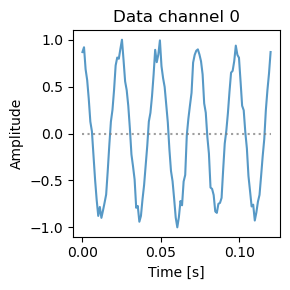

In [2]:
# --! display stationary dataset --!

datadir               = '../../data/baselines/tesla_train_filter'
timeseries_ndim       = 1
timeseries_nsample    = 120
timestep              = 0.001

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep, plot_ndata=1)

In [3]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 123
torch.manual_seed(seed)

forecast_nsample = 40
lookback_nsample = timeseries_nsample - forecast_nsample

model_cfg = kind.model_config(

    timeseries_ndim    = timeseries_ndim,
    timestep           = timestep,
    lookback_nsample   = lookback_nsample,
    forecast_nsample   = forecast_nsample,

    fun_stat = {
        'data'   : 8
    },

    fun_trans = {
        'data'   : 8
    },

    param_kernsize_stat  = 40,
    param_kernsize_trans = 10,

    mean_att_used = True,
    var_att_used  = False,
)

model = kind.model(model_cfg)

In [4]:
# --! perform only one phase of training: stationary mean --!

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/baselines/tesla_train_filter',
    'transdatadir'          : None,
    'mixdatadir'            : None,
    'timeseries_nsample'    : timeseries_nsample,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 300,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

t_start = time.time()

# --! train the stationary operator of KIND and move to the next fit phase
loss_stat_mean = model.fit(trainparam)
model.fit_next()

t_end     = time.time()
t_elapsed = t_end - t_start
print(f'inf >> training time elapsed: {t_elapsed:.1f} seconds')

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> training time elapsed: 194.4 seconds


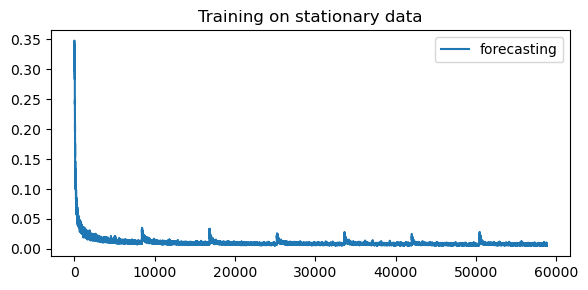

In [5]:
# --!--------------------------------------------------------------------------
# --! plot training statistics

with torch.no_grad():
    plt.figure(figsize=(6, 3))

    plt.title('Training on stationary data')
    plt.plot(loss_stat_mean[0], label='forecasting')
    plt.legend()

    plt.tight_layout()
    plt.show()

### Trained model evaluation

In [6]:
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var): Linear(in_features=8, out_features=8, bias=False)
    (pre_mean_dec): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=40, bias=Tru

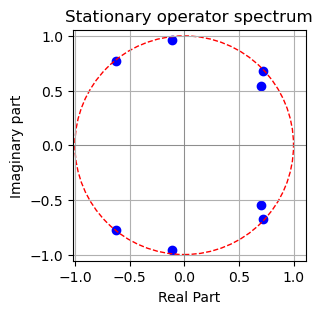

tensor([-0.6245+0.7746j, -0.6245-0.7746j, -0.1159+0.9605j, -0.1159-0.9605j,
         0.7174+0.6791j,  0.7174-0.6791j,  0.7008+0.5460j,  0.7008-0.5460j])


In [7]:
# --! visualize stationary operator eigenvalues --!

with torch.no_grad():
    utils_plot.plot_eigs(model)

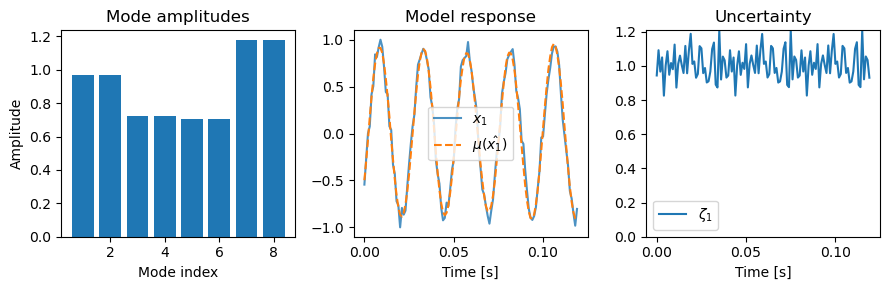

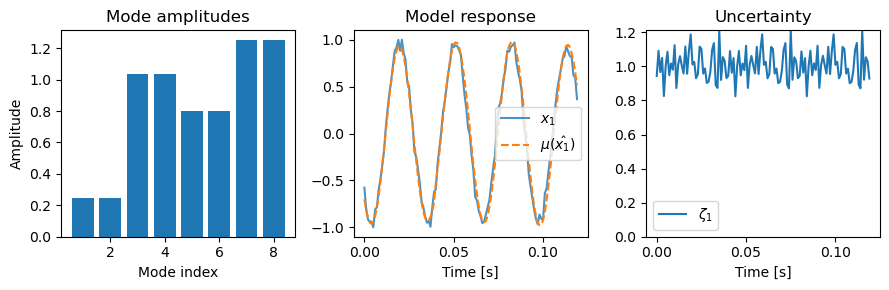

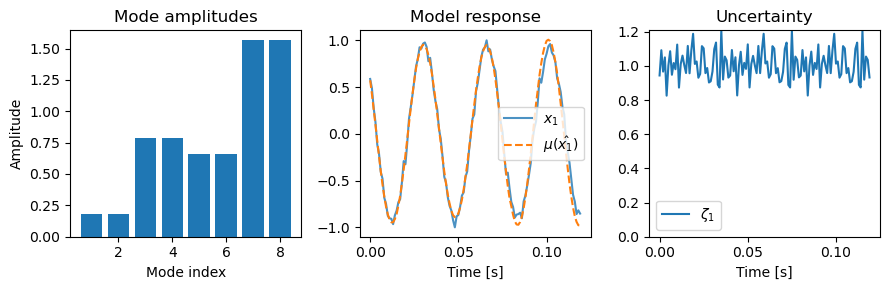

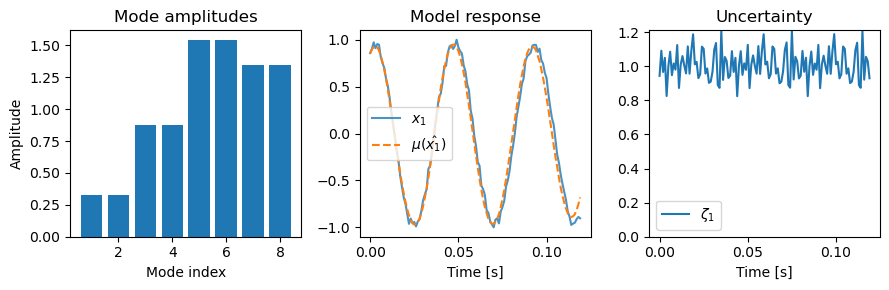

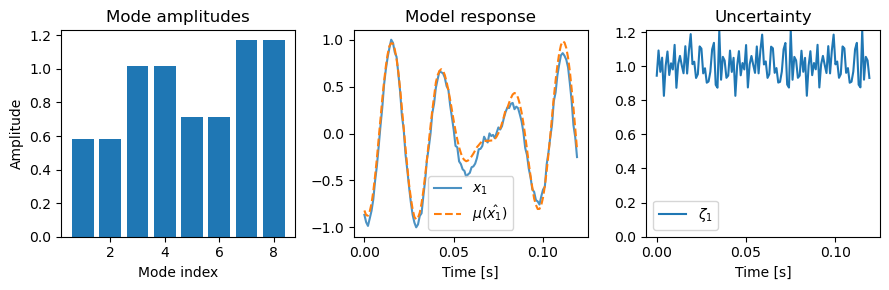

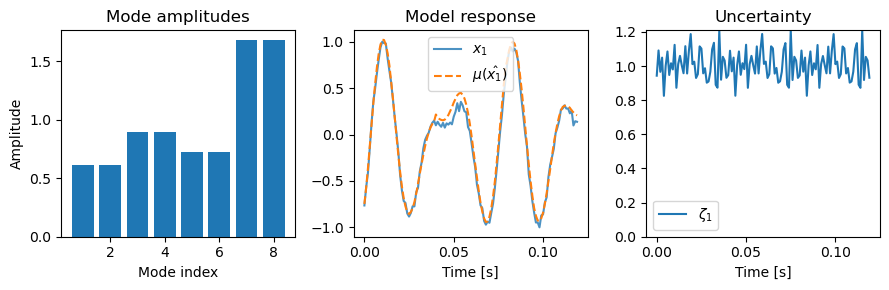

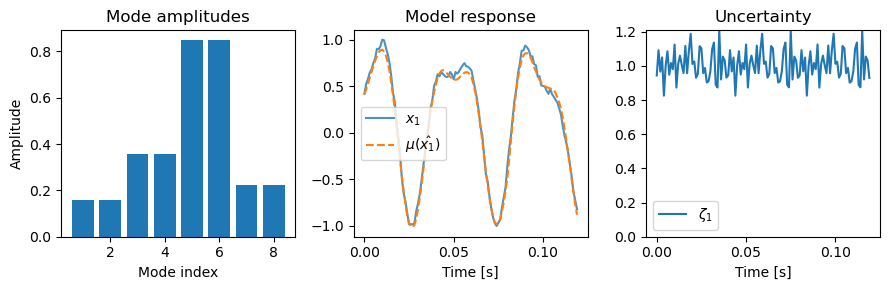

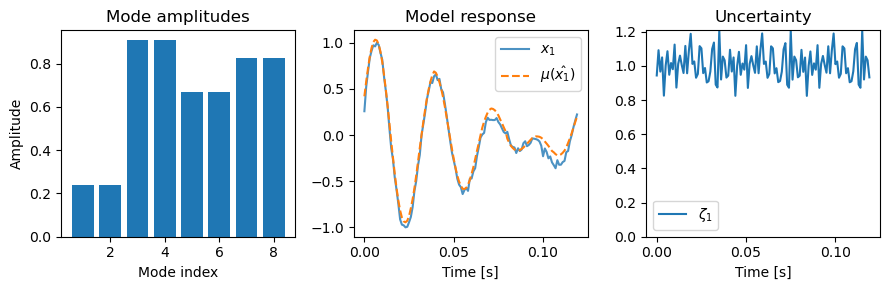

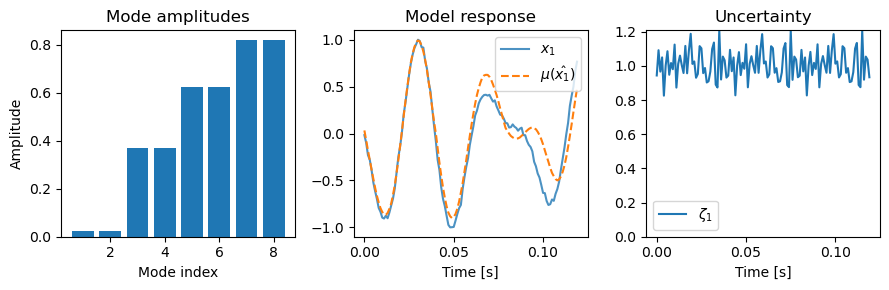

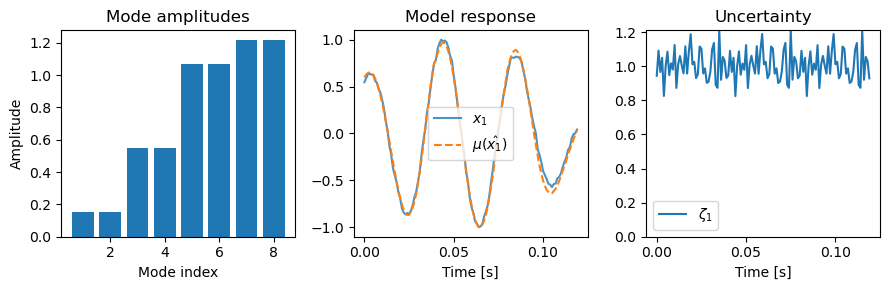

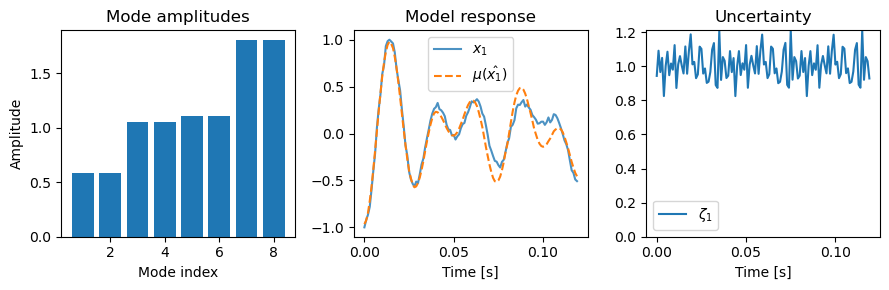

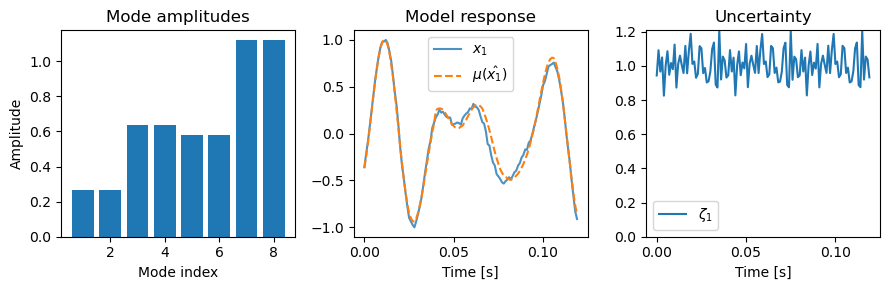

In [8]:
# --! analyze the contribution of stationary operator eigenvalues --!

datadir            = '../../data/baselines/tesla_train_filter'
timeseries_nsample = 120

with torch.no_grad():
    for jtimeseries in range(12):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

In [9]:
# --! determine the maximum residual of the stationary operator --!

datadir            = '../../data/baselines/tesla_train_filter'
timeseries_nsample = 120
maxerr_stat        = 5e-2
label_stat         = utils_data.label_stationarity(model, maxerr_stat, datadir, timeseries_nsample)

# --! print the number of timeseries still identified as transient
trans_ndata = len(torch.nonzero(~label_stat))
print(' ')
if trans_ndata == 0:
    print(f'inf >> all data are labeled as stationary when maximum residual is {res_max_stat:.1e}')
else:
    print(f'wrn >> there are still {trans_ndata} data labeled as transient')
print(' ')

# --! save the maximum residual of the stationary operator
model.maxerr_stat = maxerr_stat

 
wrn >> there are still 18 data labeled as transient
 


In [10]:
# --! save the trained model --!

modelsaved = True

if modelsaved:
    torch.save(model, '../../models/baselines/tesla_kind_filter.pt')